In [1]:
import siibra
from nilearn import plotting, image
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import plotly.graph_objects as go

import pyNN.neuron as sim
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

[siibra:INFO] Version: 1.0.1-alpha.10
[siibra:WARNING] This is a development release. Use at your own risk.
[siibra:INFO] Please file bugs and issues at https://github.com/FZJ-INM1-BDA/siibra-python.
/home/tkmcg/neuron-env/lib/python3.12/site-packages/pyNN/neuron/__init__.py:14: UserWarning: mpi4py not available
  warnings.warn("mpi4py not available")


In [14]:
#class to get random points based on the STN in the Julich Brain CYTOARCHITECTURE
#old
class Julich_brain_cyto_random_point_generator:
    def __init__(self,parcellation, region, space):
        #obtain the brain region required
        self.region = siibra.get_region(parcellation, region)
        
        #get the space required
        self.space = self.region.spaces.get(space)

    
        self.region_map = self.region.get_regional_map(space, maptype="statistical")
        self.NIfTI_region = self.region_map.fetch()
        self.region_data = self.NIfTI_region.get_fdata()
        self.affine = self.NIfTI_region.affine
        print(self.affine)


        # Flatten and mask out zero or invalid voxels
        self.region_data_flat = self.region_data.flatten()
        self.region_data_valid_probs = self.region_data_flat[self.region_data_flat > 0]

        #normalise the probabilities to work with random choice
        self.region_data_valid_probs /= self.region_data_valid_probs.sum()  

        ## Get voxel indices (i,j,k) of valid voxels
        self.region_data_indices = np.argwhere(self.region_data > 0)


    def sample_points_in_voxels(self, number_points):
        coordinates = np.zeros(shape=(number_points, 3))
        for i in range(0,number_points):            
            index = np.random.choice(len(self.region_data_valid_probs), p=self.region_data_valid_probs)
            voxel_coord = self.region_data_indices[index]

            # Add random offset in voxel space
            offset = np.random.normal(0, 0.33,3)
            voxel_point = voxel_coord + offset           
            
            # Convert to world coordinate
            voxel_point = image.coord_transform(voxel_point[0], voxel_point[1], voxel_point[2], self.affine)
            #voxel_point = self.affine @ voxel_point
            
            while True:
                if (10.1 < voxel_point[0] < 13.1) and (-17.7 < voxel_point[1] < -14.7):
                    index = np.random.choice(len(self.region_data_valid_probs), p=self.region_data_valid_probs)
                    voxel_coord = self.region_data_indices[index]

                    # Add random offset in voxel space
                    offset = np.random.normal(0, 0.33,3)
                    voxel_point = voxel_coord + offset           
            
                    # Convert to world coordinate
                    voxel_point = image.coord_transform(voxel_point[0], voxel_point[1], voxel_point[2], self.affine)
                    #voxel_point = self.affine @ voxel_point
                else:
                    break              
            
            
            coordinates[i] = voxel_point
            
        return coordinates

        

IndentationError: unexpected indent (1608464499.py, line 63)

In [19]:
#class to get random points based on the STN in the Julich Brain CYTOARCHITECTURE
#new with space to for leads
class Julich_brain_cyto_random_point_generator:
    def __init__(self, parcellation, region, space, stimulating_electrode_position, encapsulation):
        #obtain the brain region required
        self.region = siibra.get_region(parcellation, region)
        
        #get the space required
        self.space = self.region.spaces.get(space)

    
        self.region_map = self.region.get_regional_map(space, maptype="statistical")
        self.NIfTI_region = self.region_map.fetch()
        self.region_data = self.NIfTI_region.get_fdata()
        self.affine = self.NIfTI_region.affine
        print(self.affine)


        # Flatten and mask out zero or invalid voxels
        self.region_data_flat = self.region_data.flatten()
        self.region_data_valid_probs = self.region_data_flat[self.region_data_flat > 0]

        #normalise the probabilities to work with random choice
        self.region_data_valid_probs /= self.region_data_valid_probs.sum()  

        ## Get voxel indices (i,j,k) of valid voxels
        self.region_data_indices = np.argwhere(self.region_data > 0)

        #stimulating electrode position and encapsulation
        self.stimulating_electrode_position = stimulating_electrode_position
        self.encapsulation = encapsulation
        

     
    def sample_points_in_voxels(self, number_points):
        indices = np.random.choice(len(self.region_data_valid_probs), size = number_points, p=self.region_data_valid_probs)
        voxel_coords = self.region_data_indices[indices]

        offsets = np.random.normal(0, 0.33, size=(number_points, 3))
        voxel_points = voxel_coords + offsets

        ones = np.ones((number_points, 1))
        vox_hom = np.hstack([voxel_points, ones])          # (N,4)
        world_points = (self.affine @ vox_hom.T).T[:, :3]

        #remove points from the encapsulation layer
        x_min, x_max, y_min, y_max = self.stimulating_electrode_position[0]-self.encapsulation, self.stimulating_electrode_position[0]+self.encapsulation, self.stimulating_electrode_position[1]-self.encapsulation, self.stimulating_electrode_position[1]+self.encapsulation
        
        
        
        mask = ~(
        (x_min < world_points[:, 0]) & (world_points[:, 0] < x_max) &
        (y_min < world_points[:, 1]) & (world_points[:, 1] < y_max))

        if mask.sum() < number_points:
            # recursively fill remaining points
            missing = number_points - mask.sum()
            extra = self.sample_points_in_voxels(missing)
            world_points = np.vstack([world_points[mask], extra])
        else:
            world_points = world_points[mask][:number_points]
    
        return world_points

In [15]:
#class to get random points based on the STN in the Julich Brain CYTOARCHITECTURE
class Julich_brain_cyto_random_point_generator_xtra:
    def __init__(self,parcellation, region, space):
        #obtain the brain region required
        self.region = siibra.get_region(parcellation, region)
        
        #get the space required
        self.space = self.region.spaces.get(space)

    
        self.region_map = self.region.get_regional_map(space, maptype="statistical")
        self.NIfTI_region = self.region_map.fetch()
        self.region_data = self.NIfTI_region.get_fdata()
        self.affine = self.NIfTI_region.affine
        


        # Flatten and mask out zero or invalid voxels
        self.region_data_flat = self.region_data.flatten()
        self.region_data_valid_probs = self.region_data_flat[self.region_data_flat > 0]

        #normalise the probabilities to work with random choice
        self.region_data_valid_probs /= self.region_data_valid_probs.sum()  

        ## Get voxel indices (i,j,k) of valid voxels
        self.region_data_indices = np.argwhere(self.region_data > 0)


    def sample_points_in_voxels(self, number_points):
        coordinates = np.zeros(shape=(number_points, 4))
        for i in range(0,number_points):
            index = np.random.choice(len(self.region_data_valid_probs), p=self.region_data_valid_probs)
            voxel_coord = self.region_data_indices[index]

            # Add random offset in voxel space
            #offset = np.random.uniform(0, 1,3)
            #voxel_point = voxel_coord + offset
            
            x_coords = self.region_data_indices[:, 0]
            y_coords = self.region_data_indices[:, 1]
            z_coords = self.region_data_indices[:, 2]

            sequential_distances_x = np.diff(x_coords)
            sequential_distances_y = np.diff(y_coords)
            sequential_distances_z = np.diff(z_coords)

            avg_x_distance = sum(sequential_distances_x)/len(sequential_distances_x)
            avg_y_distance = sum(sequential_distances_y)/len(sequential_distances_y)
            avg_z_distance = sum(sequential_distances_z)/len(sequential_distances_z)

            offset_x = np.random.uniform(0, avg_x_distance)
            offset_y = np.random.uniform(0, avg_y_distance)
            offset_z = np.random.uniform(0, avg_z_distance)

            offset = np.array([offset_x,offset_y,offset_z])

            voxel_point = voxel_coord + offset
            
            # Convert to world coordinate
            voxel_point = np.append(voxel_point, 1)
            voxel_point = self.affine @ voxel_point
            coordinates[i] = voxel_point
            
        return coordinates[:, 0], coordinates[:, 1], coordinates[:, 2]


In [20]:
parcellation = "JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1" 
region = "STN (Subthalamus) left"
space = "MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC"
stimulating_electrode = np.array([-11600,-16200,-9100])/1000
encapsulation = 1.5


random_point_generator = Julich_brain_cyto_random_point_generator(parcellation,region,space, stimulating_electrode, encapsulation)

random_point_generator.sample_points_in_voxels(10)

[[   1.    0.    0.  -96.]
 [   0.    1.    0. -132.]
 [   0.    0.    1.  -78.]
 [   0.    0.    0.    1.]]


array([[ -8.35292136, -14.39059485, -13.01168883],
       [-13.20847605, -19.77649286,  -9.74901331],
       [-14.11584648, -17.23306449,  -9.97407548],
       [-13.72983661, -16.18192708,  -9.97871775],
       [-12.76931318, -11.27373422,  -6.02760251],
       [-11.88146168, -14.48232276, -14.68033898],
       [-12.27433542, -10.91161111, -11.50004135],
       [ -6.36101478, -12.78394529, -10.53531689],
       [ -9.1027905 , -12.41093591,  -9.32513364],
       [ -7.86569635, -16.65112548, -11.77868578]])

In [4]:
def set_axes_equal(ax):
    '''Set 3D plot axes to equal scale.'''
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    x_middle = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_middle = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_middle = np.mean(z_limits)

    plot_radius = 0.5 * max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])

In [21]:
##### Add in the STN neurons and change the geometry to match the coupling project with DC current ####
v_init = -68
rng_seed = 856
n = 1000
rotation_angle = 0.610865
parcellation = "JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1" 
region = "STN (Subthalamus) right"
space = "MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC"
stimulating_electrode = np.array([11600,-16200,-9100])/1000
encapsulation = 1.5


############ Setup the simulation##########
sim.setup(timestep=0.01)

###########set up the neuron type##############
cortical_type = sim.HH_cond_exp()
STN_type = sim.HH_cond_exp()

########## create a population of neurons ###############
cortical_pop = sim.Population(n, cortical_type, initial_values={'v': v_init}, label="Cortical neurons")
STN_pop = sim.Population(n, STN_type, initial_values={'v': v_init}, label="STN neurons")

######## positions of the cells #######################
random_point_generator = Julich_brain_cyto_random_point_generator(parcellation,region,space, stimulating_electrode, encapsulation)
STN_space = random_point_generator.sample_points_in_voxels(n)


cortical_pop.positions[0], cortical_pop.positions[1],cortical_pop.positions[2] = STN_space[:,0], STN_space[:,1], STN_space[:,2]
#STN_pop.positions[0], STN_pop.positions[1],STN_pop.positions[2] = STN_space[0], STN_space[1], STN_space[2]

#STN_pop.positions[:3] *= 1000
#cortical_pop.positions[:3] *= 1000


############ set up the current ##############
start = 600
stop = 1000
cortical_pop.inject(sim.DCSource(start=start, stop=stop, amplitude=1))

############# make the connections ############
syn_CorticalCollateralSTN = StaticSynapse(weight=0.12, delay=1)

prj_CorticalSTN = Projection(
    cortical_pop,
    STN_pop,
    FixedNumberPreConnector(n=5, allow_self_connections=False),
    syn_CorticalCollateralSTN,
    source="collateral(0.5)",
    receptor_type="excitatory",
)

######## Record membrane potential from the STN neurons #############
#cortical_pop.record('v')

STN_pop.sample(10).record('v')

######### Run the simulation ###########
sim.run(1000)
'''
############ Get and plot data ############
data = STN_pop.get_data().segments[0]
vm = data.filter(name="v")[0]

plt.plot(vm.times, vm)
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("PyNN simulation (HH neuron)")
plt.show()
'''
####### Clean up ###########
sim.end()

[[   1.    0.    0.  -96.]
 [   0.    1.    0. -132.]
 [   0.    0.    1.  -78.]
 [   0.    0.    0.    1.]]


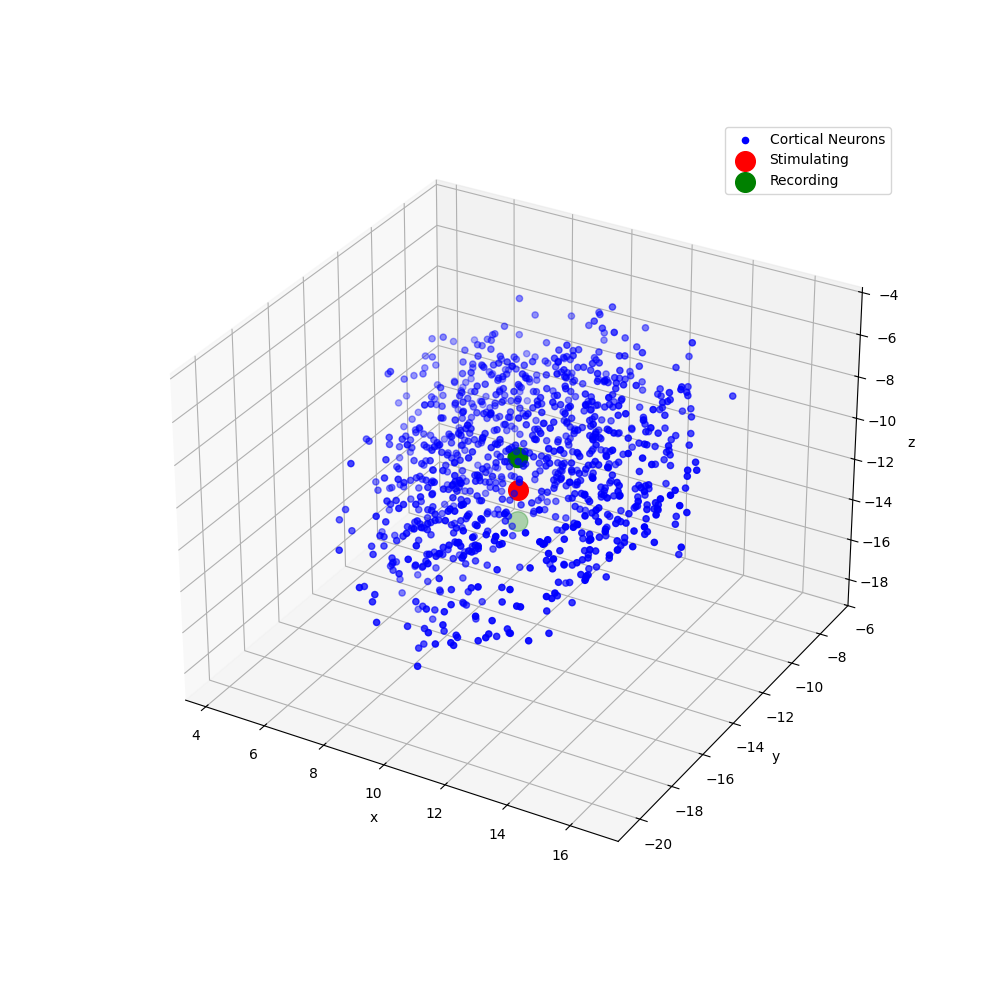

In [22]:
###### plot where the neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget

################################################
#volume_activated_tissue = 2.5e+11 #[6e+9, 10e+9, 15e+9]

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('x')
ax.set_zlabel('z')
ax.set_ylabel('y')


##### add in the cortical neurons##############
x_points_clean_ctx = cortical_pop.positions[0]
y_points_clean_ctx = cortical_pop.positions[1]
z_points_clean_ctx = cortical_pop.positions[2]

ax.scatter(x_points_clean_ctx, y_points_clean_ctx, z_points_clean_ctx, c='blue', label = "Cortical Neurons")
ax.scatter(np.array([11.600]), np.array([-16.200]), np.array([-9.100]), c='red', label = "Stimulating", s=200)
ax.scatter(np.array([11.600,11.600]), np.array([-16.200,-16.200]), np.array([-7.600,-10.600]), c='green', label = "Recording", s=200)
'''
##### add in the STN neurons##########
x_points_clean_stn = STN_pop.positions[0]
y_points_clean_stn = STN_pop.positions[1]
z_points_clean_stn = STN_pop.positions[2]

ax.scatter(x_points_clean_stn, z_points_clean_stn, y_points_clean_stn, c='green', s=100, label = "STN Neurons")


###### add in the electric field ########
theta = np.linspace(0, 2 * np.pi, 100)
phi = np.linspace(0, np.pi, 50)
theta, phi = np.meshgrid(theta, phi)
r_sphere = ((3*volume_activated_tissue)/(4*np.pi))**(1/3)

x_sphere = r_sphere * np.sin(phi) * np.cos(theta)
y_sphere = r_sphere * np.sin(phi) * np.sin(theta)
z_sphere = r_sphere * np.cos(phi)


#Plot ellipsoidal
# Set of all spherical angles:
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)

# Cartesian coordinates that correspond to the spherical angles:
# (this is the equation of an ellipsoid):
x = 4176 * np.outer(np.cos(u), np.sin(v))
y = 3080 * np.outer(np.sin(u), np.sin(v))
z = 2961 * np.outer(np.ones_like(u), np.cos(v))

#rotate around the rostral-caudal axis
x_dash = np.cos(0.785398)*x - np.sin(0.785398)*y
y_dash = np.cos(0.785398)*y + np.cos(0.785398)*x

ax.plot_surface(x_dash, z, y_dash, alpha = 0.15, color = "g")
ax.plot_surface(x_sphere, y_sphere, z_sphere, alpha=0.25, color = "r", label = "VTA")
set_axes_equal(ax)

print(r_sphere)
'''
ax.legend()

plt.show()